# MFCC Implementation

In [1]:
import numpy
import scipy.io.wavfile
from scipy.fftpack import dct

sample_rate, signal = scipy.io.wavfile.read('OSR_us_000_0010_8k.wav')  # File assumed to be in the same directory
signal = signal[0:int(3.5 * sample_rate)]  # Keep the first 3.5 seconds

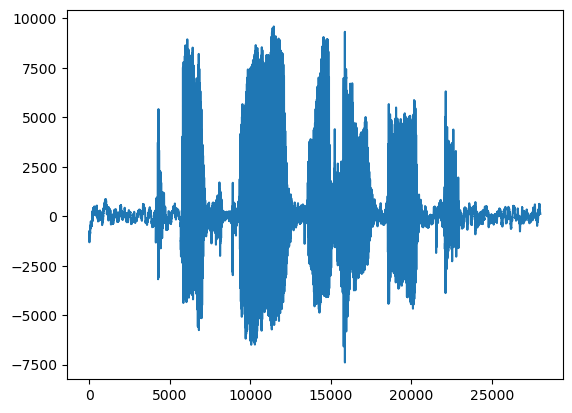

In [2]:
import matplotlib.pyplot as plt
plt.plot(signal)
plt.show()

# Pre-Emphasis

The first step is to apply a pre-emphasis filter on the signal to amplify the high frequencies. A pre-emphasis filter is useful in several ways: (1) balance the frequency spectrum since high frequencies usually have smaller magnitudes compared to lower frequencies, (2) avoid numerical problems during the Fourier transform operation and (3) may also improve the Signal-to-Noise Ratio (SNR).

In [3]:
pre_emphasis = 0.97

emphasized_signal = numpy.append(signal[0], signal[1:] - pre_emphasis * signal[:-1])

# Framing

After pre-emphasis, we need to split the signal into short-time frames. The rationale behind this step is that frequencies in a signal change over time, so in most cases it doesn’t make sense to do the Fourier transform across the entire signal in that we would lose the frequency contours of the signal over time. To avoid that, we can safely assume that frequencies in a signal are stationary over a very short period of time. Therefore, by doing a Fourier transform over this short-time frame, we can obtain a good approximation of the frequency contours of the signal by concatenating adjacent frames.

Typical frame sizes in speech processing range from 20 ms to 40 ms with 50% (+/-10%) overlap between consecutive frames. Popular settings are 25 ms for the frame size, frame_size = 0.025 and a 10 ms stride (15 ms overlap), frame_stride = 0.01.

In [5]:
frame_size = 0.025  # Frame size in seconds
frame_stride = 0.01  # Frame stride in seconds

frame_length, frame_step = frame_size * sample_rate, frame_stride * sample_rate  # Convert from seconds to samples
signal_length = len(emphasized_signal)
frame_length = int(round(frame_length))
frame_step = int(round(frame_step))
num_frames = int(numpy.ceil(float(numpy.abs(signal_length - frame_length)) / frame_step))  # Make sure that we have at least 1 frame

pad_signal_length = num_frames * frame_step + frame_length
z = numpy.zeros((pad_signal_length - signal_length))
pad_signal = numpy.append(emphasized_signal, z) # Pad Signal to make sure that all frames have equal number of samples without truncating any samples from the original signal

indices = numpy.tile(numpy.arange(0, frame_length), (num_frames, 1)) + numpy.tile(numpy.arange(0, num_frames * frame_step, frame_step), (frame_length, 1)).T
frames = pad_signal[indices.astype(numpy.int32, copy=False)]

# Window
After slicing the signal into frames, we apply a window function such as the Hamming window to each frame. A Hamming window has the following form:

w[n]=0.54−0.46cos(2πnN−1)

where, 0≤n≤N−1
, N
 is the window length. Plotting the previous equation yields the following plot:

In [6]:
frames *= numpy.hamming(frame_length)


# Fourier-Transform and Power Spectrum
We can now do an N
-point FFT on each frame to calculate the frequency spectrum, which is also called Short-Time Fourier-Transform (STFT), where N
 is typically 256 or 512, NFFT = 512; and then compute the power spectrum (periodogram) using the following equation:

P=|FFT(xi)|2N

where, xi
 is the ith
 frame of signal x
. This could be implemented with the following lines:

In [9]:
NFFT = 512
mag_frames = numpy.absolute(numpy.fft.rfft(frames, NFFT))  # Magnitude of the FFT
pow_frames = ((1.0 / NFFT) * ((mag_frames) ** 2))  # Power Spectrum

# filter Banks
The final step to computing filter banks is applying triangular filters, typically 40 filters, nfilt = 40 on a Mel-scale to the power spectrum to extract frequency bands. The Mel-scale aims to mimic the non-linear human ear perception of sound, by being more discriminative at lower frequencies and less discriminative at higher frequencies. We can convert between Hertz (f
) and Mel (m
) using the following equations:

m=2595log10(1+f700)

f=700(10m/2595−1)

Each filter in the filter bank is triangular having a response of 1 at the center frequency and decrease linearly towards 0 till it reaches the center frequencies of the two adjacent filters where the response is 0, as shown in this figure:

Mel-Scaled Filters
Filter bank on a Mel-Scale

This can be modeled by the following equation (taken from here):

Hm(k)={0k<f(m−1)  k−f(m−1)f(m)−f(m−1)f(m−1)≤k<f(m)  1k=f(m)  f(m+1)−kf(m+1)−f(m)f(m)<k≤f(m+1)  0k>f(m+1)

In [11]:
low_freq_mel = 0
nfilt = 40
high_freq_mel = (2595 * numpy.log10(1 + (sample_rate / 2) / 700))  # Convert Hz to Mel
mel_points = numpy.linspace(low_freq_mel, high_freq_mel, nfilt + 2)  # Equally spaced in Mel scale
hz_points = (700 * (10**(mel_points / 2595) - 1))  # Convert Mel to Hz
bin = numpy.floor((NFFT + 1) * hz_points / sample_rate)

fbank = numpy.zeros((nfilt, int(numpy.floor(NFFT / 2 + 1))))
for m in range(1, nfilt + 1):
    f_m_minus = int(bin[m - 1])   # left
    f_m = int(bin[m])             # center
    f_m_plus = int(bin[m + 1])    # right

    for k in range(f_m_minus, f_m):
        fbank[m - 1, k] = (k - bin[m - 1]) / (bin[m] - bin[m - 1])
    for k in range(f_m, f_m_plus):
        fbank[m - 1, k] = (bin[m + 1] - k) / (bin[m + 1] - bin[m])
filter_banks = numpy.dot(pow_frames, fbank.T)
filter_banks = numpy.where(filter_banks == 0, numpy.finfo(float).eps, filter_banks)  # Numerical Stability
filter_banks = 20 * numpy.log10(filter_banks) 

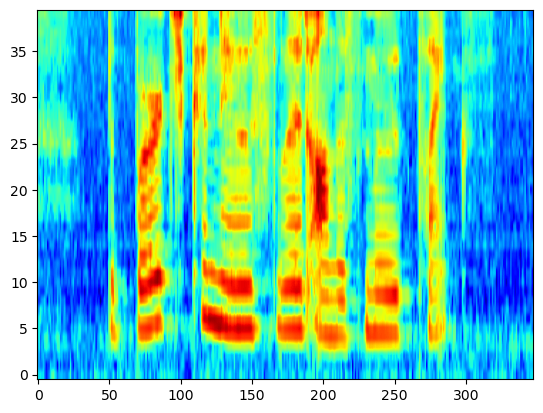

In [12]:
plt.imshow(filter_banks.T, origin='lower', aspect='auto', cmap='jet')

# Mel-frequency Cepstral Coefficients (MFCCs)
It turns out that filter bank coefficients computed in the previous step are highly correlated, which could be problematic in some machine learning algorithms. Therefore, we can apply Discrete Cosine Transform (DCT) to decorrelate the filter bank coefficients and yield a compressed representation of the filter banks. Typically, for Automatic Speech Recognition (ASR), the resulting cepstral coefficients 2-13 are retained and the rest are discarded; num_ceps = 12. The reasons for discarding the other coefficients is that they represent fast changes in the filter bank coefficients and these fine details don’t contribute to Automatic Speech Recognition (ASR).

In [14]:
num_ceps = 12
mfcc = dct(filter_banks, type=2, axis=1, norm='ortho')[:, 1 : (num_ceps + 1)] # Keep 2-13


In [16]:
cep_lifter = 22
(nframes, ncoeff) = mfcc.shape
n = numpy.arange(ncoeff)
lift = 1 + (cep_lifter / 2) * numpy.sin(numpy.pi * n / cep_lifter)
mfcc *= lift  #*

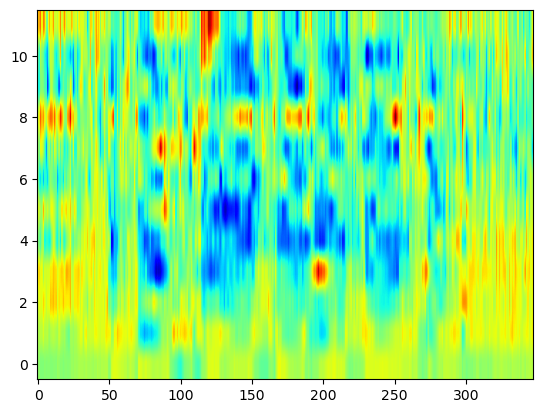

In [17]:
plt.imshow(mfcc.T, origin='lower', aspect='auto', cmap='jet')

# Mean Normalisation

In [18]:
filter_banks -= (numpy.mean(filter_banks, axis=0) + 1e-8)

In [19]:
mfcc -= (numpy.mean(mfcc, axis=0) + 1e-8)


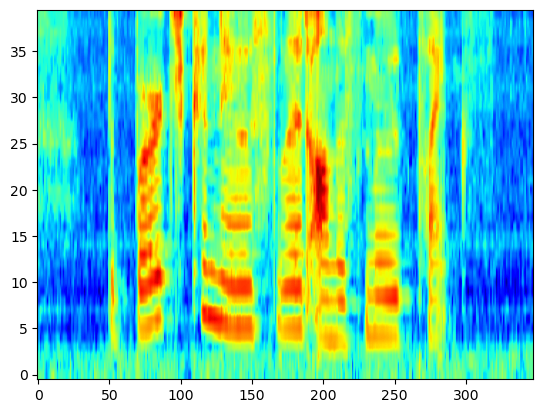

In [21]:
plt.imshow(filter_banks.T, origin='lower', aspect='auto', cmap='jet')


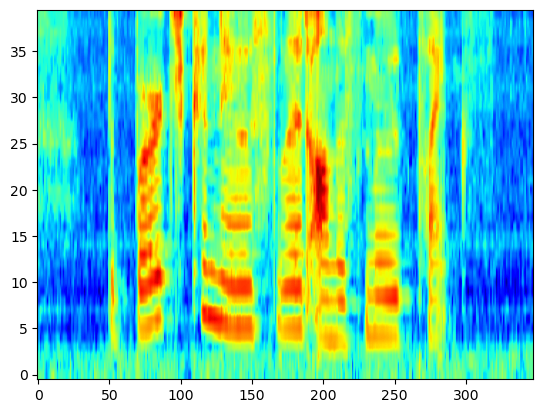

In [22]:
plt.imshow(filter_banks.T, origin='lower', aspect='auto', cmap='jet')